# Cardinality based power index ($\Upsilon$ values) Example:

The purpose of this notebook is to demonstrate the implementation of $\Upsilon$ power-index in the `powerXAI` package, using an example. The example we consider is insipired from [Explainability is NOT a Game](https://arxiv.org/abs/2307.07514) paper: $\{x_1,x_2,x_3\}$ is the feature set, each taking on values from $\{0,1\}$; the binary classifier $\kappa$, classifies each data-pt as follows:

 | $x_1$ | $x_2$ | $x_3$ | $\kappa$ (classifier) |
 | :-: | :-: | :-: | :-: |
 | 0 | 0 | 0 | 0 |
 | 0 | 0 | 1 | 1 |
 | 0 | 1 | 0 | 1 |
 | 0 | 1 | 1 | 0 |
 | 1 | 0 | 0 | 0 |
 | 1 | 0 | 1 | 0 |
 | 1 | 1 | 0 | 0 |
 | 1 | 1 | 1 | 0 |

 In this example, we will demonstrate the explanantion of the instance $\langle \langle0,0,0\rangle, \kappa=0  \rangle$, using $\Upsilon$-values across different value functions.


In [ ]:
def classifier( data_pt: list[int] )-> int:
  """ Returns the value of classifier corresponding to the example 
      in explanantion is not a game
      
      Args:
      data_pt (list[int]): A binary list of length 3.
      
      Returns:
      int: The value of classifier.
  """

  if ( data_pt == [0, 0, 1] or
       data_pt == [0, 1, 0]
       ):       return 1

  else :    return 0

The value of $\Upsilon_i$ measures the contribution of adding the $i$-th feature to the explanation set. For instance, suppose we want to investigate the contribution of adding a $i$-th feature for the instance $\langle \langle0,0,0\rangle, \kappa=0  \rangle$. Then $\Upsilon_3$ would indicate the influence of adding a 3rd feature to a explanability set of cardinality 2. 

We will us the above case as a running example. Following this thought, we have the value for $\Upsilon_3$ as follows:

In [ ]:
from itertools import product
import math
from powerxai import upsilon_value

def similarity_set( features: list[int], fixed_data_pt: list[int] )-> list[int]:
  """ Returns the set of data points which agree on the features of
  the fixed_data_pt
  
  Args:
    features (list[int]): A listr of features.
    fixed_data_pt (list[int]): The reference data point.
  
  Returns:
    list[int]: The list of data points acquired. 
  """
  

  if features :
    prod = product( [0, 1], repeat=3 )
    data_pts = []

    for x in prod:
      k = 1

      for y in features:
        if( x[ y ] != fixed_data_pt[ y ] ): k = 0

      if( k == 1 ):     data_pts.append ( x )

    return data_pts

  else:
    return []
  
def aggregation_similarity_set( players: list[int],
                          input: list[int], 
                          fixed_data_pt = [0,0,0] )-> float:
  """value function as defined in the example of Explanation is not a game
  
  Args: 
    players (list[int]): List of players to be passed on.
    input (list[int]): The coalition of features we ask the value for.
    fixed_data_pt (list[int]): The point w.r.t. which we find the strength.
    
  Returns:
    float: The value w.r.t. to input.
  """

  sim = similarity_set( input, fixed_data_pt )
  sim_list = [list(x) for x in sim]

  sum = 0

  for x in sim_list:  sum = sum + classifier (x)

  final_sum = sum / math.pow( 2, 3 - (len (input)) )

  return final_sum

print(f'The upsilon-value (contribution) of adding the 3rd feature: {upsilon_value( 3, [0,1,2], aggregation_similarity_set )}')

The upsilon-value (contribution) of adding the 3rd feature: -0.3333333333333333


For the instance we mentioned, the $\Upsilon$-value corresponding to adding $1,2$ and $3$ features are given below. Additionally, we contrast their relative strength in the form of a graph. 

The upsilon-value (contribution) of adding the 1st feature: 0.3333333333333333
The upsilon-value (contribution) of adding the 2nd feature: 0.0
The upsilon-value (contribution) of adding the 3rd feature: -0.3333333333333333


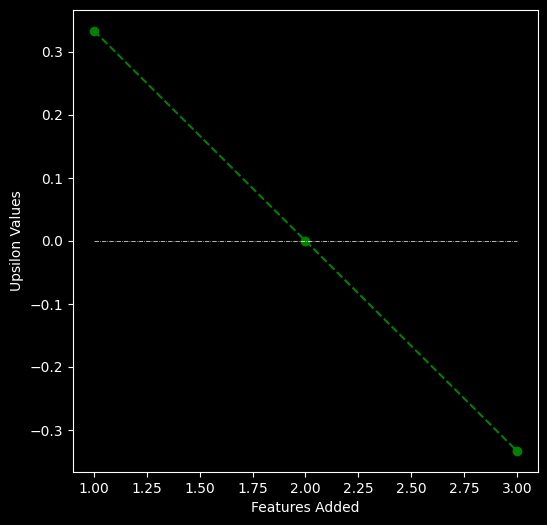

In [ ]:
from powerxai import upsilon_value
import matplotlib.pyplot as plt
def Upsilon_value_check_aggregation_similarity_set():

  x_1 = upsilon_value( 1, [0,1,2], aggregation_similarity_set )
  x_2 = upsilon_value( 2, [0,1,2], aggregation_similarity_set )
  x_3 = upsilon_value( 3, [0,1,2], aggregation_similarity_set )

  print(f'The upsilon-value (contribution) of adding the 1st feature: {x_1}')
  print(f'The upsilon-value (contribution) of adding the 2nd feature: {x_2}')
  print(f'The upsilon-value (contribution) of adding the 3rd feature: {x_3}')

  xaxis = [1, 2, 3]
  yaxis = [x_1, x_2, x_3]

  plt.style.use( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (6)
  fig.set_figheight (6)

  plt.xlabel( "Features Added" )
  plt.ylabel( "Upsilon Values" )
  plt.plot( xaxis, yaxis, 'go', linestyle = 'dashed' )
  plt.plot( xaxis, [0,0,0], 'w-.', linewidth = 0.5 )
  plt.show()

Upsilon_value_check_aggregation_similarity_set ()

Hence, it is worthwhile to add one feature to the explanantion. Adding a second feature to it is non-consequential. However, adding a 3rd feature leads to a loss of explainability. 

## Changing the value function

The calculation of value function depens on the value function. In the above case, we used the `aggregation_similarity_set` function from the Explanability is NOT a game paper 
To demonstrate the dependence of $\Upsilon$-values on the value function, we consider two additional cases:

### Aggregation Similarity Set Inverse

We investigate the instance of $\langle \langle0,0,0\rangle, \kappa=0  \rangle$, altering the value function to `aggregation_similarity_set_inverse`.
$\Upsilon$-values for this particular value function are given below, followed by a graph that constrasts them.


The upsilon-value of adding the 1st feature: 0.3333333333333333
The upsilon-value of adding the 2nd feature: 0.0
The upsilon-value of adding the 3rd feature: 0.16666666666666666


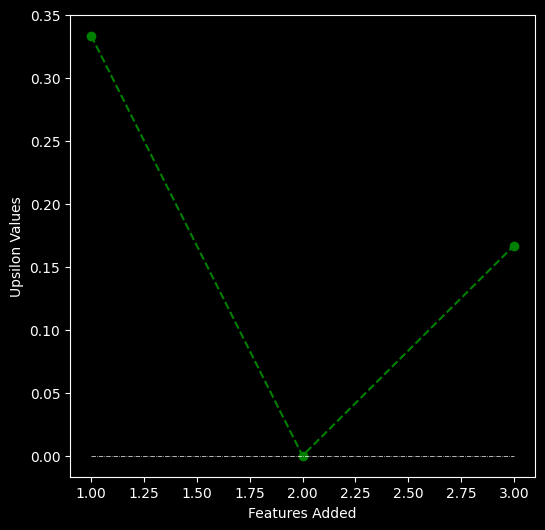

In [ ]:
from powerxai import upsilon_value
import matplotlib.pyplot as plt

import math
def aggregation_similarity_set_inverse( players: list[int] ,
                                  input: list[int],
                                  fixed_data_pt = [0,0,0] )-> float:
  """Strength function counting the number 0s provided by the classifier,
  The normalisation factor is the same as in the previous case.
  
  Args: 
    players (list[int]): List of players to be passed on.
    input (list[int]): The coalition of features we ask the value for.
    fixed_data_pt (list[int]): The point w.r.t. which we find the strength.
    
  Returns:
    float: The value w.r.t. to input.
  """

  sim = similarity_set( input, fixed_data_pt )
  sim_list = [list(x) for x in sim]

  sum = 0

  for x in sim_list:

    sum = sum + (1 - classifier( x ))


  final_sum = sum / math.pow( 2, 4 - (len (input)) )


  return final_sum

def Upsilon_value_check_aggregation_sim_set ():
  x_1 = upsilon_value( 1, [0,1,2], aggregation_similarity_set_inverse )
  x_2 = upsilon_value( 2, [0,1,2], aggregation_similarity_set_inverse )
  x_3 = upsilon_value( 3, [0,1,2], aggregation_similarity_set_inverse )

  print(f'The upsilon-value of adding the 1st feature: {x_1}')
  print(f'The upsilon-value of adding the 2nd feature: {x_2}')
  print(f'The upsilon-value of adding the 3rd feature: {x_3}')

  xaxis = [1, 2, 3]
  yaxis = [x_1, x_2, x_3]

  plt.style.use( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (6)
  fig.set_figheight (6)

  plt.xlabel("Features Added")
  plt.ylabel("Upsilon Values")

  plt.plot(xaxis, yaxis, 'go', linestyle = 'dashed')
  plt.plot(xaxis, [0,0,0], 'w-.', linewidth = 0.5)
  plt.show()

Upsilon_value_check_aggregation_sim_set ()

In this case too, adding one feature to explainability is worthwhile, followed by the neutraility of adding the second one. However, in contrast to the `aggregation_similarity_set` function, adding a third feature still leads to a gain in explainability. 

### Aggregation Sufficiency 

We investigate the instance of $\langle \langle0,0,0\rangle, \kappa=0  \rangle$, altering the value function to `aggregation_sufficiency`.
$\Upsilon$-values for this particular value function are given below, followed by a graph that constrasts them.

The upsilon-value of 1: 0.08333333333333333
The upsilon-value of 2: 0.3333333333333333
The upsilon-value of 3: 1.0833333333333333


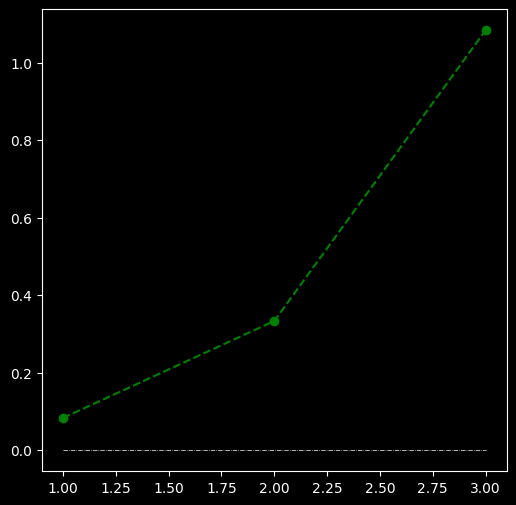

In [ ]:
from itertools import product
from powerxai.coalitions import coalitions
from powerxai.upsilon_value import upsilon_value
import matplotlib.pyplot as plt

def partition_of_features(feature_set: list[int],
                           reference =0 )-> list[int]:
  """Returns the set of all data points which agree on the feature_set. 
  
  Args: 
    feature_set (list[int]): List of features considered.
    reference (list[int]): A reference data point.
    
  Returns:
    list[int]: A list of data points. 
  """


  full = list( product( (0,1), repeat=3 ) )
  list_for_feature_set =[]
  used = []
  groups = []


  for x in full:
    a = [x[i-1] for i in feature_set]
    list_for_feature_set.append( a )

  list_of_8 = [x for x in range (0,8)]

  while( set(used) != set(list_of_8) ):
    list_without_used = [x for x in list_of_8 if x not in used]
    ind = []
    b = list_for_feature_set[list_without_used[0]]

    for i in list_without_used:
      if(list_for_feature_set[i] == b):
        used.append( i )
        ind.append( i )

    groups.append( ind )

  if( reference == 0 ): return groups
  
  else:
    k = full.index (reference)
    for x in groups:
      if (k in x): return x

def sufficiency_check_with_reference( feature_set: list[int],
                                      reference: list[int] )-> bool:
  """Checks whether a feature_set is sifficient w.r.t. a reference.
  
  Args: 
    feature_set (list[int]): The considered feature_set.
    reference (list[int]): The data point we check against.
    
  Returns:
    bool: The truth value of the sufficiency check.
  """

  group = partition_of_features( feature_set, reference )
  full = list (product ( (0,1), repeat=3 ))
  classification_1 = classifier ( list(reference) )

  for i in group:
    classification_2 = classifier( list( full[i] ) )
    if(classification_1 != classification_2): return False

  return True

def sufficiency_check( feature_set: list[int] )-> bool:
  """
    Checks whether a feature set is sufficient. 

    Args:
      feature_set (list[int]): List of features.

    Return:
      bool: Truth value of the sufficiency check.
  """

  groups = partition_of_features( feature_set )
  full = list( product( (0,1), repeat=3 ))

  for i in groups:

    classification_1 = classifier( list( full[ i[0] ]) )

    for j in i:
      classification_2 = classifier( list( full[j] ) )
      if(classification_1 != classification_2): return False

  return True

def aggregation_sufficency_with_reference( feature_set: list[int],
                                          reference: list[int] )-> float:
  """
    Value function defined w.r.t. sufficiency aggregartion. 

    Args:
      feature_set (list[int]): List of features.
      reference (list[int]): The reference data point.

    Return:
      float: Truth value of the sufficiency check.
  """

  possible_sub_feature_sets= coalitions( feature_set )
  sum =0

  for x in possible_sub_feature_sets:
    if( sufficiency_check_with_reference( x, reference ) ):      sum = sum + 1

  return sum

def aggregation_sufficiency( players: list[int],
                       feature_set: list[int] )-> float:
  """value function defined w.r.t. sufficiency aggregartion.
  
    Args:
      players (list[int]): list of players to be passed on.
      feature_set (list[int]): The input of the function.

    Returns:
      float: The corresponding value.
  """

  full = list( product( (0,1), repeat=3 ) )
  sum = 0

  for x in full:
    sum = sum + aggregation_sufficency_with_reference( feature_set, x )

  return sum / 16

def Upsilon_value_check_aggregation_suff ():
  x_1 = upsilon_value( 1, [0,1,2], aggregation_sufficiency )
  x_2 = upsilon_value( 2, [0,1,2], aggregation_sufficiency )
  x_3 = upsilon_value( 3, [0,1,2], aggregation_sufficiency )

  print(f'The upsilon-value of 1: {x_1}')
  print(f'The upsilon-value of 2: {x_2}')
  print(f'The upsilon-value of 3: {x_3}')

  xaxis = [1, 2, 3]
  yaxis = [x_1, x_2, x_3]

  plt.style.use( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth(6)
  fig.set_figheight(6)

  plt.plot(xaxis, yaxis, 'go', linestyle = 'dashed')
  plt.plot(xaxis, [0,0,0], 'w-.', linewidth = 0.5)
  plt.show()

Upsilon_value_check_aggregation_suff ()


In this case, we see that adding more features leads to increased explainability. This behavior can be attributed to the monotonicity of `aggregation_sufficiency` function.

## Comparisons between the values

Lastly, we demonstrate how the $\Upsilon$-value behaves w.r.t. the three value value functions. The considered instance is still $\langle \langle 0,0,0\rangle ,\kappa=0\rangle$.

In [ ]:
from powerxai import upsilon_value
import matplotlib.pyplot as plt

def comparison_based_on_value_functions_Upsilon_values ():

  xaxis =[]

  yaxis_sim_set =[]
  yaxis_sim_set_inverse =[]
  yaxis_sim_suff =[]

  for i in range(1, 4):
    xaxis. append( i )

  for i in range(1, 4):
    yaxis_sim_set. append( upsilon_value(i, [0,1,2], aggregation_similarity_set) )

  for i in range(1, 4):
    yaxis_sim_set_inverse. append( upsilon_value(i, [0,1,2], aggregation_similarity_set_inverse) )

  for i in range(1, 4):
    yaxis_sim_suff. append( upsilon_value(i, [0,1,2], aggregation_sufficiency) )

  plt.style.use( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth(6)
  fig.set_figheight(6)

  plt.xlabel("Features Added")
  plt.ylabel("Upsilon Values")

  plt.plot(xaxis, yaxis_sim_set, 'go', linestyle = 'dashed', label= 'simlarity set')
  plt.plot(xaxis, yaxis_sim_set_inverse, 'rs', linestyle = 'dashed', label= 'simlarity set inverse')
  plt.plot(xaxis, yaxis_sim_suff, 'c*', linestyle = 'dashed', label= 'sufficiency')

  plt.legend()

comparison_based_on_value_functions_Upsilon_values ()

NameError: name 'aggregation_similarity_set' is not defined

## Comparsion between Shapley and $\Upsilon$-values

Keeping the instance  $\langle \langle 0,0,0\rangle ,\kappa=0\rangle$ fixed, in this section, we compare the Shapley and $\Upsilon$ values w.r.t. the above defined value functions. There are three cases:

1. Aggregation based value function w.r.t. similarity set

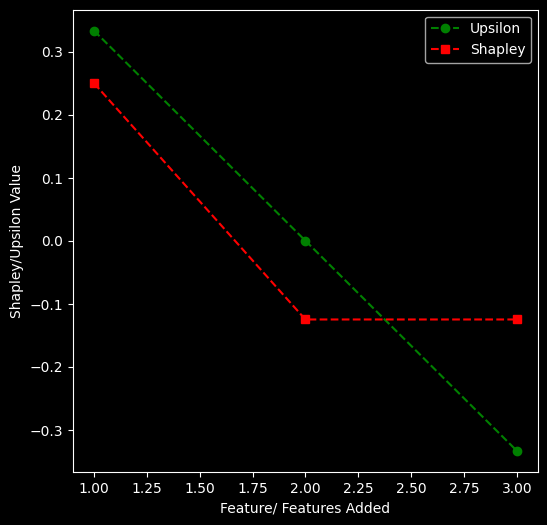

In [ ]:
from powerxai.shapley_value import shapley_value

def comparison_between_values_similarity_set():

  xaxis =[]

  yaxis_upsilon =[]
  yaxis_shapley =[]

  for i in range(1, 4):
    xaxis. append( i )

  for i in range(1, 4):
    yaxis_upsilon. append( upsilon_value(i, [0,1,2], aggregation_similarity_set) )

  for i in range(1, 4):
    yaxis_shapley. append( shapley_value(i-1, [0,1,2], aggregation_similarity_set) )

  plt.style.use( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth(6)
  fig.set_figheight(6)

  plt.xlabel("Feature/ Features Added")
  plt.ylabel("Shapley/Upsilon Value")
  plt.plot(xaxis, yaxis_upsilon, 'go', linestyle = 'dashed', label= 'Upsilon')
  plt.plot(xaxis, yaxis_shapley, 'rs', linestyle = 'dashed', label ='Shapley')

  plt.legend()

comparison_between_values_similarity_set()

2. Aggregation based value function w.r.t. similarity set inverse

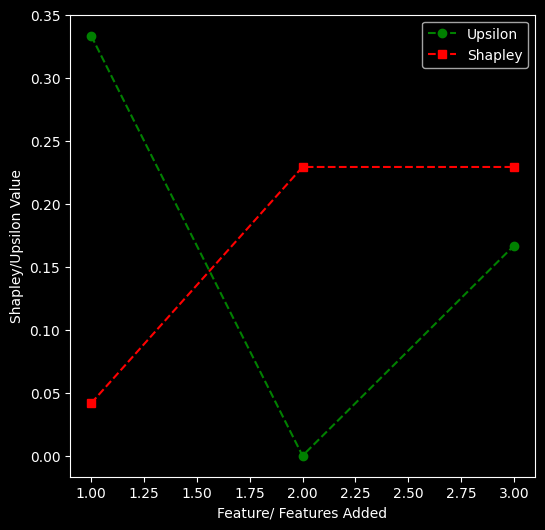

In [ ]:
from powerxai.shapley_value import shapley_value

def comparison_between_values_similarity_set_inverse():

  xaxis =[]

  yaxis_upsilon =[]
  yaxis_shapley =[]

  for i in range(1, 4):
    xaxis. append( i )

  for i in range(1, 4):
    yaxis_upsilon. append( upsilon_value(i, [0,1,2], aggregation_similarity_set_inverse) )

  for i in range(1, 4):
    yaxis_shapley. append( shapley_value(i-1, [0,1,2], aggregation_similarity_set_inverse) )

  plt.style.use( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth(6)
  fig.set_figheight(6)

  plt.xlabel("Feature/ Features Added")
  plt.ylabel("Shapley/Upsilon Value")
  plt.plot(xaxis, yaxis_upsilon, 'go', linestyle = 'dashed', label= 'Upsilon')
  plt.plot(xaxis, yaxis_shapley, 'rs', linestyle = 'dashed', label ='Shapley')

  plt.legend()

comparison_between_values_similarity_set_inverse()

3. Aggregation based value function w.r.t. sufficiency.

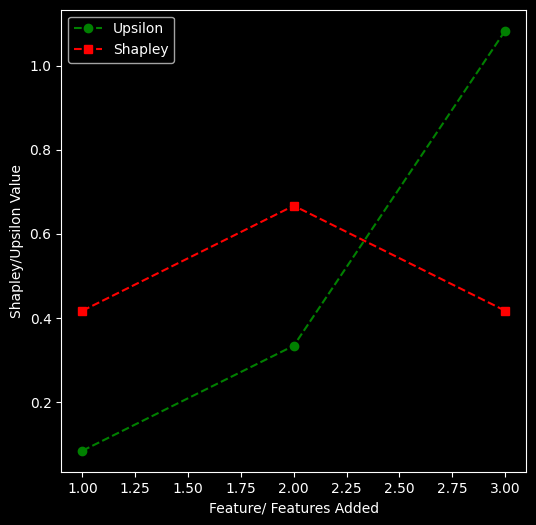

In [ ]:
from powerxai.shapley_value import shapley_value

def comparison_between_values_sufficiency():

  xaxis =[]

  yaxis_upsilon =[]
  yaxis_shapley =[]

  for i in range(1, 4):
    xaxis. append (i)

  for i in range(1, 4):
    yaxis_upsilon. append ( upsilon_value(i, [0,1,2], aggregation_sufficiency) )

  for i in range(1, 4):
    yaxis_shapley. append ( shapley_value(i-1, [0,1,2], aggregation_sufficiency) )

  plt.style.use( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth(6)
  fig.set_figheight(6)

  plt.xlabel("Feature/ Features Added")
  plt.ylabel("Shapley/Upsilon Value")
  plt.plot(xaxis, yaxis_upsilon, 'go', linestyle = 'dashed', label= 'Upsilon')
  plt.plot(xaxis, yaxis_shapley, 'rs', linestyle = 'dashed', label ='Shapley')

  plt.legend()

comparison_between_values_sufficiency()